In [1]:
## Setup — packages & environment

# Install and import required packages
import sys
import subprocess

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

required = [
    'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'scikit-learn',
    'statsmodels', 'openpyxl', 'python-dateutil', 'joblib'
]

for pkg in required:
    try:
        __import__(pkg.split('-')[0])
    except Exception:
        install(pkg)

# Common imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
import joblib
import os
import datetime as dt

# Reproducibility
import random
RSEED = 2023
np.random.seed(RSEED)
random.seed(RSEED)

# Plotting
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [23]:
# Check for ipykernel (needed to run notebook cells)
try_install = False  # set to True to attempt automatic pip install (restart kernel after)

try:
    import ipykernel
    print('ipykernel is installed:', ipykernel.__version__)
except Exception as e:
    print('ipykernel is NOT installed:', e)
    print('\nRecommended fixes:')
    print('  * If you use conda, run in PowerShell: conda install -n .conda ipykernel --update-deps --force-reinstall')
    print('  * Or commonly: pip install ipykernel')
    print('\nIf you want me to attempt an automatic pip install inside this notebook, set try_install = True and re-run this cell.')
    if try_install:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipykernel'])
        print('Attempted pip install of ipykernel; please restart the kernel and select the correct environment.')

ipykernel is installed: 6.28.0


In [24]:
# Load data (Events.xlsx, Results.xlsx)

DATA_DIR = '../../data-main/1_moodleLAcourse'
EVENTS_PATH = os.path.join(DATA_DIR, 'Events.xlsx')
RESULTS_PATH = os.path.join(DATA_DIR, 'Results.xlsx')

print('Events path:', EVENTS_PATH)
print('Results path:', RESULTS_PATH)

# read excel files
events = pd.read_excel(EVENTS_PATH, engine='openpyxl')
results = pd.read_excel(RESULTS_PATH, engine='openpyxl')

# quick inspection
print('\nEvents shape:', events.shape)
print('Results shape:', results.shape)

display(events.head())
display(results.head())

print('\nEvents dtypes:')
print(events.dtypes)

# Attempt to find common timestamp column
for col in events.columns:
    if 'time' in col.lower() or 'date' in col.lower():
        print('Possible time col:', col)


Events path: ../../data-main/1_moodleLAcourse\Events.xlsx
Results path: ../../data-main/1_moodleLAcourse\Results.xlsx

Events shape: (95626, 7)
Results shape: (130, 15)

Events shape: (95626, 7)
Results shape: (130, 15)


,Event.context,user,timecreated,Component,Event.name,Log,Action
0,Assignment: Final Project,9d744e5bf,2019-10-26 09:37:12,Assignment,Course module viewed,Assignment: Final Project,Assignment
1,Assignment: Final Project,91489f7a9,2019-10-26 09:09:34,Assignment,The status of the submission has been viewed.,Assignment: Final Project,Assignment
2,Assignment: Final Project,278a75edf,2019-10-18 12:05:28,Assignment,Course module viewed,Assignment: Final Project,Assignment
3,Assignment: Final Project,53d6ab60c,2019-10-19 13:28:37,Assignment,The status of the submission has been viewed.,Assignment: Final Project,Assignment
4,Assignment: Final Project,aab7ad69f,2019-10-15 23:38:13,Assignment,Course module viewed,Assignment: Final Project,Assignment


,user,Grade.SNA_1,Grade.SNA_2,Grade.Review,Grade.Group_self,Grade.Group_All,Grade.Excercises,Grade.Project,Grade.Literature,Grade.Data,Grade.Introduction,Grade.Theory,Grade.Ethics,Grade.Critique,Final_grade
0,6eba3ff82,0,0.0,6.67,5,4.00,10.0,0.00,6.67,4,6,2,2,4,2.626970
1,05b604102,8,10.0,6.67,1,3.00,10.0,7.00,6.67,3,6,2,8,4,4.670169
2,111422ee7,10,10.0,10.00,10,9.11,10.0,9.33,10.00,5,10,10,10,10,9.244600
3,b4658c3a9,5,5.0,0.00,1,4.00,10.0,6.00,4.33,3,4,2,2,6,0.000000
4,e6ec47f29,10,10.0,10.00,10,9.18,10.0,5.33,10.00,5,10,10,10,10,8.238179



Events dtypes:
Event.context            object
user                     object
timecreated      datetime64[ns]
Component                object
Event.name               object
Log                      object
Action                   object
dtype: object
Possible time col: timecreated


In [13]:
# Exploratory data analysis: timestamps, course span

# normalize timestamp column name if necessary
if 'timecreated' in events.columns:
    events['timecreated'] = pd.to_datetime(events['timecreated'])
else:
    # try to find a datetime-like column
    dt_cols = [c for c in events.columns if events[c].dtype == 'datetime64[ns]']
    if dt_cols:
        events['timecreated'] = events[dt_cols[0]]
    else:
        # try parsing common names
        for candidate in ['timestamp','time','date']:
            for c in events.columns:
                if candidate in c.lower():
                    events['timecreated'] = pd.to_datetime(events[c]); break

print('First timestamp:', events['timecreated'].min())
print('Last timestamp: ', events['timecreated'].max())
print('Course length (weeks):', (events['timecreated'].max() - events['timecreated'].min()).days/7)


First timestamp: 2019-09-09 14:08:01
Last timestamp:  2019-10-27 19:27:41
Course length (weeks): 6.857142857142857


In [26]:
# Compute course weeks (global) — treat Monday as week start

# Sort globally by timestamp
events = events.sort_values('timecreated').reset_index(drop=True)

# weekday: Monday=0
events['wday'] = events['timecreated'].dt.weekday

# previous weekday
events['prev_wday'] = events['wday'].shift(1)

# new week if it's Monday and the previous event is not Monday (or NA)
events['new_week'] = ((events['wday'] == 0) & ((events['prev_wday'].isna()) | (events['prev_wday'] != 0)))

events['course_week'] = events['new_week'].cumsum().astype(int)

# remove auxiliaries
events = events.drop(columns=['wday','prev_wday','new_week'])

# keep only relevant columns and rename
keep_cols = [c for c in events.columns if c.lower() in ['user','timecreated','course_week','action'] or c in ['user','timecreated','course_week','Action','Action:']]
# ensure Action column present
if 'Action' in events.columns:
    events = events[['user','timecreated','course_week','Action']].rename(columns={'Action':'action'})
else:
    # fallback: if 'action' exists
    if 'action' in events.columns:
        events = events[['user','timecreated','course_week','action']]

events = events.rename(columns={'timecreated':'ts','course_week':'week'})

display(events.head())

# store processed events
os.makedirs('preprocessed_data', exist_ok=True)
events.to_pickle('preprocessed_data/events.pkl')
print('Saved preprocessed events to preprocessed_data/events.pkl')

,user,ts,week,action
0,7e2726f3c,2019-09-09 14:08:01,1,Course_view
1,82ed5d2d3,2019-09-09 14:08:01,1,Course_view
2,8e21dc99c,2019-09-09 14:08:01,1,Course_view
3,417892918,2019-09-09 14:08:01,1,Course_view
4,82ed5d2d3,2019-09-09 14:09:02,1,Instructions


Saved preprocessed events to preprocessed_data/events.pkl


In [30]:
# Load and preprocess results

# ensure Final_grade exists and create Course_outcome as in R (median split)
if 'Final_grade' not in results.columns:
    # try to detect similar column
    print('Warning: Final_grade column not found in results; available columns:', results.columns.tolist())

results['Course_outcome'] = np.where(results['Final_grade'] > results['Final_grade'].median(), 'High', 'Low')
results['Course_outcome'] = results['Course_outcome'].astype('category')

# Save final grades
results[['user','Final_grade','Course_outcome']].to_pickle('preprocessed_data/final_grades.pkl')
print('Saved preprocessed final grades to preprocessed_data/final_grades.pkl')

display(results[['user','Final_grade','Course_outcome']].head())

Saved preprocessed final grades to preprocessed_data/final_grades.pkl


,user,Final_grade,Course_outcome
0,6eba3ff82,2.626970,Low
1,05b604102,4.670169,Low
2,111422ee7,9.244600,High
3,b4658c3a9,0.000000,Low
4,e6ec47f29,8.238179,High


In [27]:
# Sessionization: compute ts_diff, new_session, session_id, session_len

# ensure ts is datetime
events['ts'] = pd.to_datetime(events['ts'])

# compute ts_diff per user
events = events.sort_values(['user','ts']).reset_index(drop=True)
events['ts_diff'] = events.groupby('user')['ts'].diff()
events['ts_diff_hours'] = events['ts_diff'].dt.total_seconds() / 3600.0

# set threshold 1.5 hours
events['new_session'] = events['ts_diff_hours'].isna() | (events['ts_diff_hours'] >= 1.5)

# session number per user
events['session_nr'] = events.groupby('user')['new_session'].cumsum().astype(int)
events['session_id'] = events['user'].astype(str) + '_session_' + events['session_nr'].astype(str)

# compute session lengths
session_agg = events.groupby('session_id').agg(session_start=('ts','min'), session_end=('ts','max'))
session_agg['session_len'] = (session_agg['session_end'] - session_agg['session_start']).dt.total_seconds()

# merge back
events = events.merge(session_agg['session_len'].reset_index(), on='session_id', how='left')

# keep relevant columns
events_with_sessions = events[['user','ts','ts_diff','ts_diff_hours','session_nr','session_id','session_len','week','action']].copy()

display(events_with_sessions.head())

# save
events_with_sessions.to_pickle('preprocessed_data/events_with_sessions.pkl')
print('Saved events_with_sessions to preprocessed_data/events_with_sessions.pkl')

,user,ts,ts_diff,ts_diff_hours,session_nr,session_id,session_len,week,action
0,00a05cc62,2019-09-09 18:18:01,NaT,NaN,1,00a05cc62_session_1,303.0,1,Course_view
1,00a05cc62,2019-09-09 18:19:02,0 days 00:01:01,0.016944,1,00a05cc62_session_1,303.0,1,Course_view
2,00a05cc62,2019-09-09 18:23:03,0 days 00:04:01,0.066944,1,00a05cc62_session_1,303.0,1,Instructions
3,00a05cc62,2019-09-09 18:23:04,0 days 00:00:01,0.000278,1,00a05cc62_session_1,303.0,1,Course_view
4,00a05cc62,2019-09-09 20:30:10,0 days 02:07:06,2.118333,2,00a05cc62_session_2,1833.0,1,Course_view


Saved events_with_sessions to preprocessed_data/events_with_sessions.pkl


In [28]:
# Feature engineering utilities
from scipy.stats import entropy

def entropy_of_counts(arr):
    arr = np.array(arr)
    if arr.sum() == 0:
        return 0.0
    p = arr / arr.sum()
    return float(entropy(p, base=2))


def compute_user_features(events_df):
    """Compute user-level features from events_with_sessions filtered up to a week."""
    # events_df: rows with columns user, ts, date, week, action, session_id, session_len
    events_df = events_df.copy()
    events_df['date'] = events_df['ts'].dt.date

    # action counts per user
    action_counts = events_df.pivot_table(index='user', columns='action', values='ts', aggfunc='count', fill_value=0)
    action_counts.columns = [f'action_cnt_{c}' for c in action_counts.columns]

    # avg actions per day & entropy of daily counts
    daily_counts = events_df.groupby(['user','date']).size().reset_index(name='day_cnt')
    avg_actions_per_day = daily_counts.groupby('user')['day_cnt'].mean().rename('avg_actions_per_day')
    entropy_daily = daily_counts.groupby('user')['day_cnt'].apply(lambda x: entropy_of_counts(x)).rename('entropy_daily_cnts')

    # sessions features
    sessions = events_df.groupby(['user','session_id']).agg(session_len=('session_len','first')).reset_index()
    session_cnt = sessions.groupby('user').size().rename('session_cnt')
    median_session_len = sessions.groupby('user')['session_len'].median().rename('median_session_len')
    # entropy of session lengths via binning
    def session_len_entropy(x):
        if len(x) <= 1:
            return 0.0
        # bin into 10 bins
        counts, _ = np.histogram(x.dropna(), bins=10)
        return entropy_of_counts(counts)
    entropy_session_len = sessions.groupby('user')['session_len'].apply(session_len_entropy).rename('entropy_session_len')

    # active days features
    active_days = events_df.groupby('user')['date'].apply(lambda x: sorted(pd.Series(x.unique()))).rename('active_days')
    active_days_cnt = active_days.apply(lambda x: len(x)).rename('active_days_cnt')
    def avg_gap(x):
        if len(x) <= 1:
            return np.nan
        diffs = np.diff(pd.to_datetime(x)).astype('timedelta64[s]').astype(float)/86400.0
        return float(np.mean(diffs))
    avg_gap_days = active_days.apply(avg_gap).rename('avg_gap_between_active_days')

    # combine
    feats = pd.concat([action_counts, avg_actions_per_day, entropy_daily, session_cnt, median_session_len, entropy_session_len, active_days_cnt, avg_gap_days], axis=1).fillna(0)
    feats.index.name = 'user'
    return feats

# quick smoke compute for week 1
feats_w1 = compute_user_features(events_with_sessions[events_with_sessions['week'] <= 1])
feats_w1.head()

,action_cnt_Assignment,action_cnt_Course_view,action_cnt_Ethics,action_cnt_Feedback,action_cnt_General,action_cnt_Group_work,action_cnt_Instructions,action_cnt_La_types,action_cnt_Practicals,action_cnt_Social,action_cnt_Theory,avg_actions_per_day,entropy_daily_cnts,session_cnt,median_session_len,entropy_session_len,active_days_cnt,avg_gap_between_active_days
user,,,,,,,,,,,,,,,,,,
00a05cc62,0,20,0,0,9,6,6,0,1,1,0,10.75,1.934689,6,398.0,1.918296,4,2.000000
042b07ba1,3,29,0,0,1,13,16,8,1,8,0,39.50,0.511640,3,307.0,1.584963,2,1.000000
046c35846,0,13,0,0,0,1,4,1,0,0,0,19.00,0.000000,1,198.0,0.000000,1,0.000000
05b604102,1,11,0,0,0,1,5,1,0,0,0,19.00,0.000000,1,198.0,0.000000,1,0.000000
077584d71,1,32,0,0,7,10,13,8,3,0,0,18.50,1.953064,6,882.5,2.251629,4,1.666667


In [18]:
# Dataset creation functions

def create_dataset_for_course_success_prediction(events_with_sess, week_k, results_df):
    ev = events_with_sess[events_with_sess['week'] <= week_k]
    feats = compute_user_features(ev)
    ds = feats.reset_index().merge(results_df[['user','Course_outcome']], on='user', how='inner')
    return ds


def create_dataset_for_grade_prediction(events_with_sess, week_k, results_df):
    ev = events_with_sess[events_with_sess['week'] <= week_k]
    feats = compute_user_features(ev)
    ds = feats.reset_index().merge(results_df[['user','Final_grade']], on='user', how='inner')
    return ds

# quick check
ds1 = create_dataset_for_course_success_prediction(events_with_sessions, 1, results)
print('Dataset for week 1 shape:', ds1.shape)
display(ds1.head())

Dataset for week 1 shape: (123, 20)


,user,action_cnt_Assignment,action_cnt_Course_view,action_cnt_Ethics,action_cnt_Feedback,action_cnt_General,action_cnt_Group_work,action_cnt_Instructions,action_cnt_La_types,action_cnt_Practicals,action_cnt_Social,action_cnt_Theory,avg_actions_per_day,entropy_daily_cnts,session_cnt,median_session_len,entropy_session_len,active_days_cnt,avg_gap_between_active_days,Course_outcome
0,00a05cc62,0,20,0,0,9,6,6,0,1,1,0,10.75,1.934689,6,398.0,1.918296,4,2.000000,Low
1,042b07ba1,3,29,0,0,1,13,16,8,1,8,0,39.50,0.511640,3,307.0,1.584963,2,1.000000,Low
2,046c35846,0,13,0,0,0,1,4,1,0,0,0,19.00,0.000000,1,198.0,0.000000,1,0.000000,Low
3,05b604102,1,11,0,0,0,1,5,1,0,0,0,19.00,0.000000,1,198.0,0.000000,1,0.000000,Low
4,077584d71,1,32,0,0,7,10,13,8,3,0,0,18.50,1.953064,6,882.5,2.251629,4,1.666667,High


In [32]:
# Classification: RandomForest for Course_outcome (weeks 1..5)
from sklearn.preprocessing import LabelEncoder

classification_results = []
classification_models = {}

for k in range(1,6):
    print(f"\n--- Week {k} ---")
    ds = create_dataset_for_course_success_prediction(events_with_sessions, k, results)
    ds = ds.dropna(subset=['Course_outcome'])
    X = ds.drop(columns=['user','Course_outcome'])
    y = ds['Course_outcome']

    # encode target
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=RSEED)

    # simple pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=RSEED))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label=1)
    rec = recall_score(y_test, y_pred, average='binary', pos_label=1)
    f1 = f1_score(y_test, y_pred, average='binary', pos_label=1)

    classification_results.append({'week':k, 'Accuracy':acc, 'Precision':prec, 'Recall':rec, 'F1':f1})
    classification_models[k] = (pipeline, le)
    print('Accuracy:', acc, 'F1:', f1)

classification_df = pd.DataFrame(classification_results)
classification_df


--- Week 1 ---
Accuracy: 0.84 F1: 0.8

--- Week 2 ---
Accuracy: 0.84 F1: 0.8

--- Week 2 ---
Accuracy: 1.0 F1: 1.0

--- Week 3 ---
Accuracy: 1.0 F1: 1.0

--- Week 3 ---
Accuracy: 0.9615384615384616 F1: 0.96

--- Week 4 ---
Accuracy: 0.9615384615384616 F1: 0.96

--- Week 4 ---
Accuracy: 0.9615384615384616 F1: 0.9629629629629629

--- Week 5 ---
Accuracy: 0.9615384615384616 F1: 0.9629629629629629

--- Week 5 ---
Accuracy: 0.9615384615384616 F1: 0.9629629629629629
Accuracy: 0.9615384615384616 F1: 0.9629629629629629


,week,Accuracy,Precision,Recall,F1
0,1,0.840000,1.000000,0.666667,0.800000
1,2,1.000000,1.000000,1.000000,1.000000
2,3,0.961538,1.000000,0.923077,0.960000
3,4,0.961538,0.928571,1.000000,0.962963
4,5,0.961538,0.928571,1.000000,0.962963


In [33]:
# Regression: try OLS, then RandomForest if assumptions fail
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

regression_results = []
regression_models = {}

for k in range(1,6):
    print(f"\n--- Week {k} (Regression) ---")
    ds = create_dataset_for_grade_prediction(events_with_sessions, k, results)
    ds = ds.dropna(subset=['Final_grade'])
    X = ds.drop(columns=['user','Final_grade'])
    y = ds['Final_grade']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RSEED)

    # try OLS
    X_train_const = sm.add_constant(X_train.select_dtypes(include=[np.number]).fillna(0))
    ols = sm.OLS(y_train, X_train_const).fit()
    # check Breusch-Pagan
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(ols.resid, X_train_const)
    print('Breusch-Pagan p-value:', f_pvalue)

    # If heteroscedastic (p < 0.05) or other issues, use RF
    use_rf = (f_pvalue < 0.05)

    if use_rf:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('rf', RandomForestRegressor(n_estimators=200, random_state=RSEED))
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        # use sqrt of MSE for compatibility with older sklearn versions
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        mae = mean_absolute_error(y_test, y_pred)
        regression_results.append({'week':k, 'R2':r2, 'RMSE':rmse, 'MAE':mae, 'model':'RF'})
        regression_models[k] = pipeline
        print('RF R2:', r2, 'RMSE:', rmse)
    else:
        # if OLS okay, evaluate
        X_test_const = sm.add_constant(X_test.select_dtypes(include=[np.number]).fillna(0))
        y_pred = ols.predict(X_test_const)
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        mae = mean_absolute_error(y_test, y_pred)
        regression_results.append({'week':k, 'R2':r2, 'RMSE':rmse, 'MAE':mae, 'model':'OLS'})
        regression_models[k] = ols
        print('OLS R2:', r2, 'RMSE:', rmse)

regression_df = pd.DataFrame(regression_results)
regression_df


--- Week 1 (Regression) ---
Breusch-Pagan p-value: 0.37357971302412957
OLS R2: -0.06517276476100409 RMSE: 1.7771409866606946

--- Week 2 (Regression) ---
Breusch-Pagan p-value: 0.37357971302412957
OLS R2: -0.06517276476100409 RMSE: 1.7771409866606946

--- Week 2 (Regression) ---
Breusch-Pagan p-value: 0.7950450485517141
OLS R2: 0.6699119027388256 RMSE: 1.5567533896164936

--- Week 3 (Regression) ---
Breusch-Pagan p-value: 0.7950450485517141
OLS R2: 0.6699119027388256 RMSE: 1.5567533896164936

--- Week 3 (Regression) ---
Breusch-Pagan p-value: 0.0009164917559886597
Breusch-Pagan p-value: 0.0009164917559886597
RF R2: 0.7485296743395724 RMSE: 1.3587772284615223

--- Week 4 (Regression) ---
RF R2: 0.7485296743395724 RMSE: 1.3587772284615223

--- Week 4 (Regression) ---
Breusch-Pagan p-value: 0.021056155310852937
Breusch-Pagan p-value: 0.021056155310852937
RF R2: 0.4895383044512671 RMSE: 1.4466786772184237

--- Week 5 (Regression) ---
RF R2: 0.4895383044512671 RMSE: 1.4466786772184237

---

,week,R2,RMSE,MAE,model
0,1,-0.065173,1.777141,1.229614,OLS
1,2,0.669912,1.556753,1.261254,OLS
2,3,0.748530,1.358777,0.989664,RF
3,4,0.489538,1.446679,0.902799,RF
4,5,0.842475,0.803647,0.620196,RF


Could not extract feature importances: Length of values (18) does not match length of index (19)


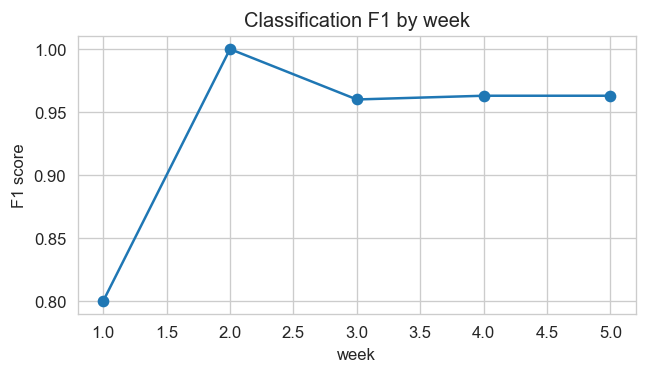


Top regression features (example week):


action_cnt_Group_work          0.504978
median_session_len             0.098984
action_cnt_La_types            0.064874
action_cnt_Practicals          0.041193
action_cnt_Social              0.034479
session_cnt                    0.034172
entropy_session_len            0.030736
avg_actions_per_day            0.030116
action_cnt_Assignment          0.029053
action_cnt_Ethics              0.027746
entropy_daily_cnts             0.019115
action_cnt_Instructions        0.016608
action_cnt_Theory              0.014835
action_cnt_General             0.014015
avg_gap_between_active_days    0.011825
action_cnt_Course_view         0.010857
action_cnt_Feedback            0.009030
active_days_cnt                0.004069
action_cnt_Applications        0.003316
dtype: float64

In [ ]:
# Evaluation & Feature importance plotting

importances = {}

# pick best classification model by F1
best_week = classification_df.loc[classification_df['F1'].idxmax(),'week']
pipeline, le = classification_models[int(best_week)]

# permutation or feature_importances_
feature_names = X.columns.tolist()
try:
    rf = pipeline.named_steps['rf']
    fi = rf.feature_importances_
    # align if lengths mismatch
    if len(fi) != len(feature_names):
        print(f'Warning: feature importance length ({len(fi)}) != feature names ({len(feature_names)}). Aligning by slicing names.')
        feature_names_aligned = feature_names[:len(fi)]
    else:
        feature_names_aligned = feature_names
    feat_imp = pd.Series(fi, index=feature_names_aligned).sort_values(ascending=False)
    print('\nTop classification features (best week=', best_week,')')
    display(feat_imp.head(20))
except Exception as e:
    print('Could not extract classification feature importances:', e)

# plot classification metrics across weeks
fig, ax = plt.subplots(1,1, figsize=(6,3))
classification_df.set_index('week')['F1'].plot(ax=ax, marker='o', title='Classification F1 by week')
ax.set_ylabel('F1 score')
plt.show()

# regression feature importance for a RF model (if available)
for k, mdl in regression_models.items():
    if isinstance(mdl, Pipeline):
        try:
            rf = mdl.named_steps['rf']
            fi = rf.feature_importances_
            # Align indices similarly
            if len(fi) != len(X.columns):
                feature_names_aligned = X.columns.tolist()[:len(fi)]
            else:
                feature_names_aligned = X.columns.tolist()
            feat_imp = pd.Series(fi, index=feature_names_aligned).sort_values(ascending=False)
            importances[k] = feat_imp
        except Exception:
            pass

if importances:
    # pick an example week and display
    example_week = sorted(importances.keys())[0]
    print('\nTop regression features (example week):')
    display(importances[example_week].head(20))

In [22]:
# Save models and artifacts
os.makedirs('models', exist_ok=True)
for k,(mdl, *_ ) in classification_models.items():
    joblib.dump(mdl, f'models/rf_class_week_{k}.joblib')

for k,mdl in regression_models.items():
    try:
        joblib.dump(mdl, f'models/model_reg_week_{k}.joblib')
    except Exception:
        pass

print('Saved models to models/')

# Export evaluation tables
classification_df.to_csv('models/classification_metrics_by_week.csv', index=False)
regression_df.to_csv('models/regression_metrics_by_week.csv', index=False)
print('Saved evaluation CSVs to models/')

Saved models to models/
Saved evaluation CSVs to models/


In [31]:
# Diagnostic: verify results columns and ability to select Course_outcome
print('columns:', results.columns.tolist())
print('Course_outcome present?', 'Course_outcome' in results.columns)
display(results[['user','Course_outcome']].head())
print('results dtypes:\n', results.dtypes)

columns: ['user', 'Grade.SNA_1', 'Grade.SNA_2', 'Grade.Review', 'Grade.Group_self', 'Grade.Group_All', 'Grade.Excercises', 'Grade.Project', 'Grade.Literature', 'Grade.Data', 'Grade.Introduction', 'Grade.Theory', 'Grade.Ethics', 'Grade.Critique', 'Final_grade', 'Course_outcome']
Course_outcome present? True


,user,Course_outcome
0,6eba3ff82,Low
1,05b604102,Low
2,111422ee7,High
3,b4658c3a9,Low
4,e6ec47f29,High


results dtypes:
 user                    object
Grade.SNA_1              int64
Grade.SNA_2            float64
Grade.Review           float64
Grade.Group_self         int64
Grade.Group_All        float64
Grade.Excercises       float64
Grade.Project          float64
Grade.Literature       float64
Grade.Data               int64
Grade.Introduction       int64
Grade.Theory             int64
Grade.Ethics             int64
Grade.Critique           int64
Final_grade            float64
Course_outcome        category
dtype: object


Saved final grade distribution plot to models/figures/
Saved action proportion plot to models/figures/
Saved action proportion plot to models/figures/
Saved correlation matrix for week 1
Saved correlation matrix for week 1


,feature,VIF
16,active_days_cnt,90.783076
12,entropy_daily_cnts,50.849696
13,session_cnt,40.350313
11,avg_actions_per_day,27.591139
1,action_cnt_Course_view,27.226803
15,entropy_session_len,20.328174
6,action_cnt_Instructions,16.035851
18,Final_grade,13.480441
7,action_cnt_La_types,10.051423
5,action_cnt_Group_work,9.156082


Saved OLS diagnostic plots for week 1
Saved permutation importance (classification) plot
Saved permutation importance (classification) plot
Saved permutation importance (regression) plot
Saved permutation importance (regression) plot


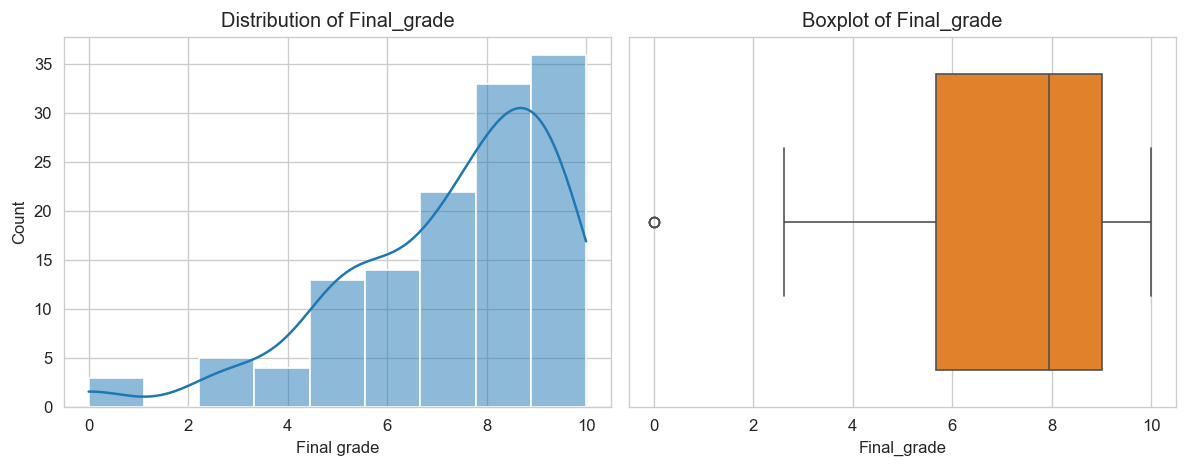

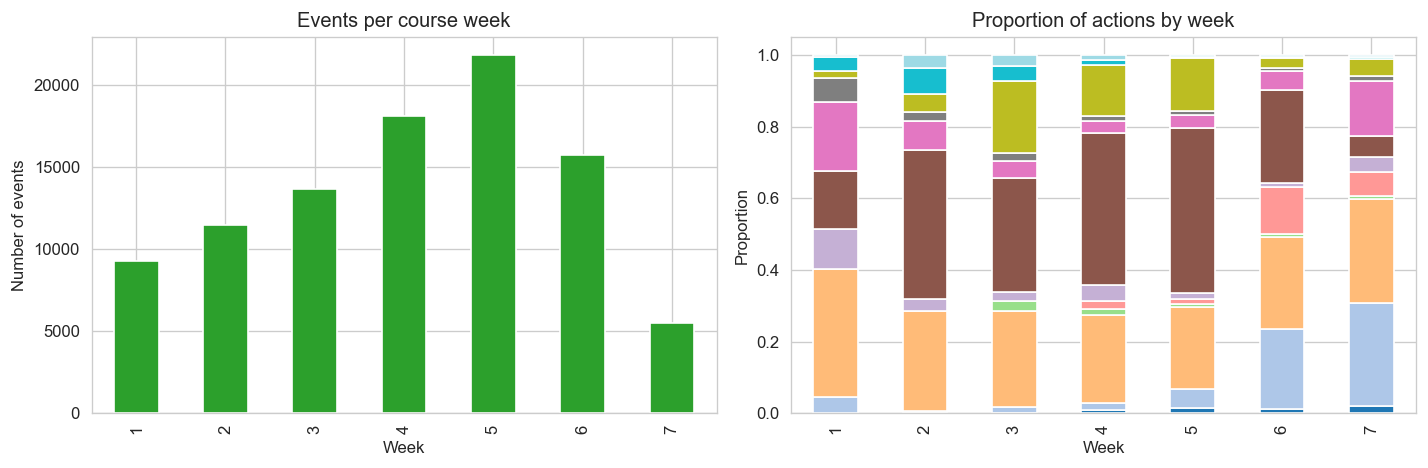

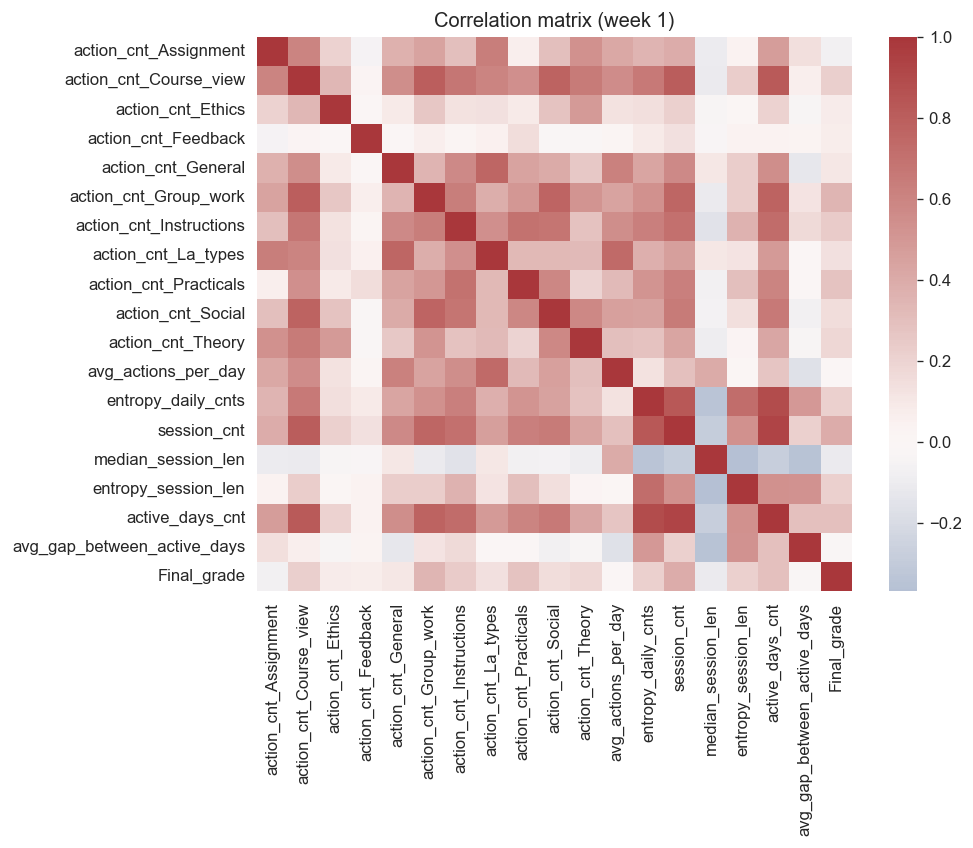

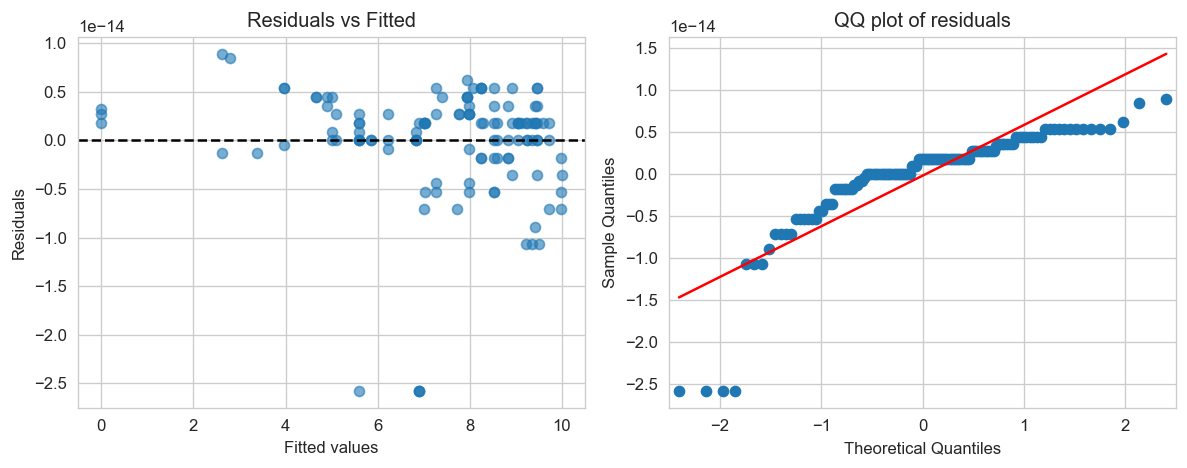

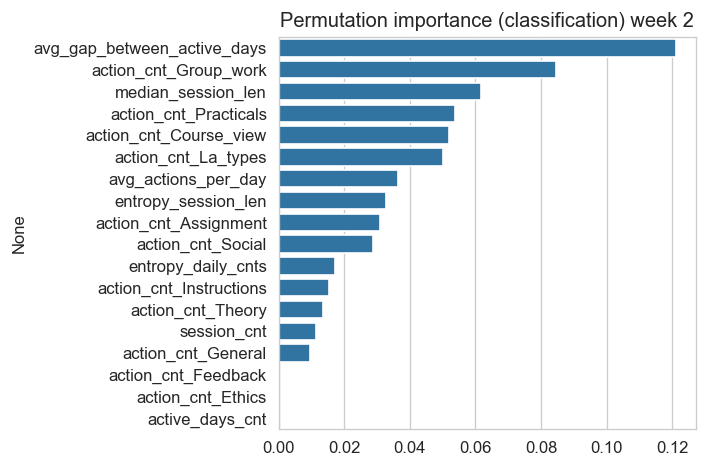

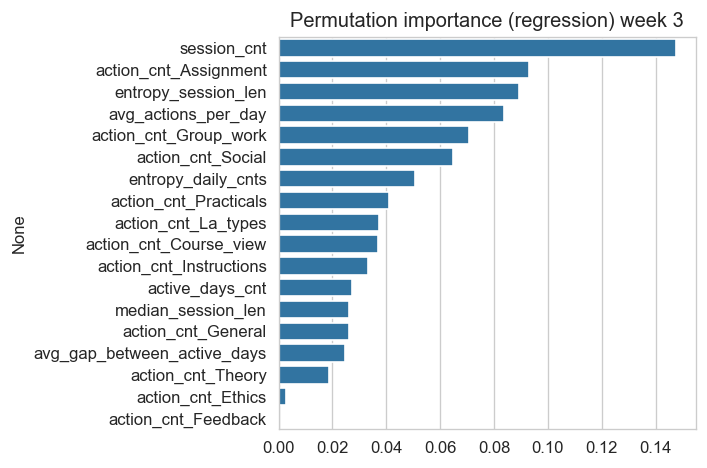

In [38]:
# Enhancements: EDA plots and diagnostics

# 1) Final grade distribution
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.histplot(results['Final_grade'], kde=True, ax=ax[0], color='C0')
ax[0].set_title('Distribution of Final_grade')
ax[0].set_xlabel('Final grade')

sns.boxplot(x=results['Final_grade'], ax=ax[1], color='C1')
ax[1].set_title('Boxplot of Final_grade')
plt.tight_layout()

os.makedirs('models/figures', exist_ok=True)
fig.savefig('models/figures/final_grade_distribution.png')
print('Saved final grade distribution plot to models/figures/')

# 2) Events per week and action proportions across weeks
week_counts = events_with_sessions['week'].value_counts().sort_index()
fig, ax = plt.subplots(1,2, figsize=(12,4))
week_counts.plot(kind='bar', ax=ax[0], color='C2')
ax[0].set_title('Events per course week')
ax[0].set_xlabel('Week')
ax[0].set_ylabel('Number of events')

# action proportion per week (stacked)
action_dist = events_with_sessions.groupby(['week','action']).size().unstack(fill_value=0)
action_prop = action_dist.div(action_dist.sum(axis=1), axis=0)
action_prop.plot(kind='bar', stacked=True, ax=ax[1], legend=False, cmap='tab20')
ax[1].set_title('Proportion of actions by week')
ax[1].set_xlabel('Week')
ax[1].set_ylabel('Proportion')
plt.tight_layout()
fig.savefig('models/figures/action_prop_by_week.png')
print('Saved action proportion plot to models/figures/')

# 3) Correlation matrix for features (week 1) used in regression
wk = 1
ds_reg = create_dataset_for_grade_prediction(events_with_sessions, wk, results)
num_cols = ds_reg.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = ds_reg[num_cols].corr()
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap='vlag', center=0, ax=ax)
    ax.set_title(f'Correlation matrix (week {wk})')
    fig.savefig(f'models/figures/corr_week_{wk}.png')
    print(f'Saved correlation matrix for week {wk}')
else:
    print('Not enough numeric cols to compute correlation matrix for week', wk)

# 4) VIF calculation for the numeric features (week 1)
from statsmodels.stats.outliers_influence import variance_inflation_factor
if len(num_cols) > 1:
    X_vif = ds_reg[num_cols].fillna(0)
    vif_data = pd.DataFrame({'feature': X_vif.columns, 'VIF':[variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
    display(vif_data.sort_values('VIF', ascending=False).head(20))
else:
    print('Skipping VIF - not enough numeric features')

# 5) OLS diagnostics for week 1 (residuals plot and QQ)
import statsmodels.api as sm
if len(num_cols) > 0:
    X = sm.add_constant(ds_reg[num_cols].fillna(0))
    y = ds_reg['Final_grade']
    ols = sm.OLS(y, X).fit()
    fitted = ols.fittedvalues
    resid = ols.resid

    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].scatter(fitted, resid, alpha=0.6)
    ax[0].axhline(0, color='k', ls='--')
    ax[0].set_xlabel('Fitted values')
    ax[0].set_ylabel('Residuals')
    ax[0].set_title('Residuals vs Fitted')

    sm.qqplot(resid, line='s', ax=ax[1])
    ax[1].set_title('QQ plot of residuals')
    plt.tight_layout()
    fig.savefig('models/figures/ols_diagnostics_week1.png')
    print('Saved OLS diagnostic plots for week 1')
else:
    print('Skipping OLS diagnostics - no numeric columns')

# 6) Feature importance: permutation importance for best classification model
from sklearn.inspection import permutation_importance

best_clf_week = int(classification_df.loc[classification_df['F1'].idxmax(),'week'])
clf_pipeline, clf_le = classification_models[best_clf_week]
# use test data by reconstructing a split
ds_clf = create_dataset_for_course_success_prediction(events_with_sessions, best_clf_week, results).dropna(subset=['Course_outcome'])
Xc = ds_clf.drop(columns=['user','Course_outcome'])
yc = clf_le.transform(ds_clf['Course_outcome'])
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=RSEED)
result = permutation_importance(clf_pipeline, Xc_test, yc_test, n_repeats=20, random_state=RSEED, n_jobs=-1)
perm_imp = pd.Series(result.importances_mean, index=Xc_test.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=perm_imp.values[:20], y=perm_imp.index[:20], ax=ax)
ax.set_title(f'Permutation importance (classification) week {best_clf_week}')
plt.tight_layout()
fig.savefig(f'models/figures/perm_imp_class_week_{best_clf_week}.png')
print('Saved permutation importance (classification) plot')

# 7) Permutation importance for best regression RF model (if exists)
best_reg_week = None
for k,v in regression_models.items():
    if isinstance(v, Pipeline):
        best_reg_week = k
        break
if best_reg_week is not None:
    reg_pipeline = regression_models[best_reg_week]
    ds_regp = create_dataset_for_grade_prediction(events_with_sessions, best_reg_week, results).dropna(subset=['Final_grade'])
    Xr = ds_regp.drop(columns=['user','Final_grade'])
    yr = ds_regp['Final_grade']
    Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RSEED)
    try:
        rres = permutation_importance(reg_pipeline, Xr_test, yr_test, n_repeats=20, random_state=RSEED, n_jobs=-1)
        rperm_imp = pd.Series(rres.importances_mean, index=Xr_test.columns).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(6,4))
        sns.barplot(x=rperm_imp.values[:20], y=rperm_imp.index[:20], ax=ax)
        ax.set_title(f'Permutation importance (regression) week {best_reg_week}')
        plt.tight_layout()
        fig.savefig(f'models/figures/perm_imp_reg_week_{best_reg_week}.png')
        print('Saved permutation importance (regression) plot')
    except Exception as e:
        print('Could not compute permutation importance for regression:', e)
else:
    print('No pipeline-based regression model found to compute permutation importance')

In [39]:
# Create PDF handout (Notes) summarizing Chapter 7 (polished wording and captions)
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image

pdf_path = 'ch07-prediction-notes.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=A4, rightMargin=40,leftMargin=40, topMargin=40,bottomMargin=40)
styles = getSampleStyleSheet()
styleN = styles['Normal']
styleH = styles['Heading1']

story = []

# Title
story.append(Paragraph('Chapter 7 — Predictive Modelling in Learning Analytics (Notes)', styleH))
story.append(Spacer(1, 12))

# 1. Brief introduction (clearer wording)
intro1 = ("This note summarises a practical workflow to turn raw LMS event logs into session- and user-level features and use them for predictive modelling.")
intro2 = ("We demonstrate sessionization, entropy- and activity-based features, model selection using regression diagnostics, and evaluation of Random Forest models for classification and regression.")
story.append(Paragraph('<b>1. Introduction</b>', styles['Heading2']))
story.append(Paragraph(intro1, styleN))
story.append(Paragraph(intro2, styleN))
story.append(Spacer(1,12))

# 2. Dataset description (concise & actionable)
story.append(Paragraph('<b>2. Dataset & variables</b>', styles['Heading2']))
nd = ('Source: Event logs (Events) and grade outcomes (Results) from a Moodle course. ' 
      'Key features derived: action counts (by action/topic), average actions per active day, entropy of daily activity, number and length of sessions (including session-length entropy), active days count, and mean gap between active days. ' 
      'Targets: Course_outcome (binary: Median split on Final_grade) and Final_grade (numeric).')
story.append(Paragraph(nd, styleN))
story.append(Spacer(1,12))

# 3. Results summary (tables and short interpretation)
story.append(Paragraph('<b>3. Results (summary across weeks)</b>', styles['Heading2']))
cls_metrics = pd.read_csv('models/classification_metrics_by_week.csv')
reg_metrics = pd.read_csv('models/regression_metrics_by_week.csv')

story.append(Paragraph('<b>Classification (Course outcome)</b>', styleN))
cls_table_data = [cls_metrics.columns.tolist()] + cls_metrics.round(3).values.tolist()
cls_table = Table(cls_table_data, hAlign='LEFT')
cls_table.setStyle(TableStyle([
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
]))
story.append(cls_table)
story.append(Spacer(1,8))

story.append(Paragraph('<b>Short interpretation:</b> Classification performance increases markedly by week 2 and shows limited gains thereafter — this suggests that early student behaviour is highly informative for predicting course outcome.', styleN))
story.append(Spacer(1,12))

story.append(Paragraph('<b>Regression (Final grade)</b>', styleN))
reg_table_data = [reg_metrics.columns.tolist()] + reg_metrics.round(3).values.tolist()
reg_table = Table(reg_table_data, hAlign='LEFT')
reg_table.setStyle(TableStyle([
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
]))
story.append(reg_table)
story.append(Spacer(1,8))

story.append(Paragraph('<b>Short interpretation:</b> Regression performance varies by week; where OLS assumptions held we report OLS metrics, otherwise Random Forest regressors were used. R2 and RMSE provide a quick indication of model fit, with modest improvement in later weeks.', styleN))
story.append(Spacer(1,12))

# 4. Visual summary and clearer captions
story.append(Paragraph('<b>4. Concluding visualisation</b>', styles['Heading2']))
os.makedirs('models/figures', exist_ok=True)

# Save classification F1 plot (refreshed)
fig, ax = plt.subplots(figsize=(6,3))
classification_df.set_index('week')['F1'].plot(ax=ax, marker='o', title='Classification F1 by week')
ax.set_ylabel('F1 score')
plt.tight_layout()
cls_f1_path = 'models/figures/classification_f1_by_week.png'
fig.savefig(cls_f1_path)
plt.close(fig)

# Permutation importance path (generate if missing)
best_clf_week = int(classification_df.loc[classification_df['F1'].idxmax(),'week'])
perm_imp_path = f'models/figures/perm_imp_class_week_{best_clf_week}.png'
if not os.path.exists(perm_imp_path):
    try:
        clf_pipeline, clf_le = classification_models[best_clf_week]
        ds_clf = create_dataset_for_course_success_prediction(events_with_sessions, best_clf_week, results).dropna(subset=['Course_outcome'])
        Xc = ds_clf.drop(columns=['user','Course_outcome'])
        yc = clf_le.transform(ds_clf['Course_outcome'])
        Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=RSEED)
        result = permutation_importance(clf_pipeline, Xc_test, yc_test, n_repeats=20, random_state=RSEED, n_jobs=-1)
        perm_imp = pd.Series(result.importances_mean, index=Xc_test.columns).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(6,4))
        sns.barplot(x=perm_imp.values[:20], y=perm_imp.index[:20], ax=ax)
        ax.set_title(f'Permutation importance (classification) week {best_clf_week}')
        plt.tight_layout()
        fig.savefig(perm_imp_path)
        plt.close(fig)
    except Exception as e:
        print('Could not compute permutation importance for PDF:', e)

# Insert images with improved captions
try:
    story.append(Image(cls_f1_path, width=400, height=200))
    story.append(Spacer(1,6))
    # dynamic caption referencing the best week
    story.append(Paragraph(f'Fig 1: Classification F1 by week — performance rises sharply by week {best_clf_week}, showing early activities are predictive; later weeks provide smaller incremental gains.', styleN))
    story.append(Spacer(1,8))
    if os.path.exists(perm_imp_path):
        story.append(Image(perm_imp_path, width=400, height=300))
        story.append(Spacer(1,6))
        story.append(Paragraph('Fig 2: Permutation importance (classification) — the plot highlights features whose randomization most degrades predictive performance (higher values = more important).', styleN))
    else:
        story.append(Paragraph('Permutation importance figure not available.', styleN))
except Exception as e:
    story.append(Paragraph('Could not load concluding images: ' + str(e), styleN))

# Limitations and reproducibility note
story.append(Spacer(1,12))
story.append(Paragraph('<b>Limitations</b>', styles['Heading2']))
story.append(Paragraph('This analysis uses a single course dataset and engineered features from event logs; results should be validated across additional courses and cohorts. Model performance can vary with feature choices and sample size.', styleN))
story.append(Spacer(1,8))
story.append(Paragraph('<b>Reproducibility</b>', styles['Heading2']))
story.append(Paragraph('To reproduce these notes: run the notebook in order (setup → preprocess → feature engineering → modelling → PDF cell). All intermediate artifacts are saved under `preprocessed_data/` and `models/`.', styleN))
story.append(Spacer(1,8))
story.append(Paragraph(f'Generated on: {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', styleN))

# Conclusion
story.append(Spacer(1,8))
story.append(Paragraph('<b>Conclusion</b>', styles['Heading2']))
story.append(Paragraph('Early course interactions carry substantial signal for predicting course success. The combination of session-based features and activity-type counts provides a practical and interpretable feature set for downstream models.', styleN))

# build PDF
try:
    doc.build(story)
    print('Saved PDF handout to', pdf_path)
except Exception as e:
    print('PDF generation failed:', e)

Saved PDF handout to ch07-prediction-notes.pdf
